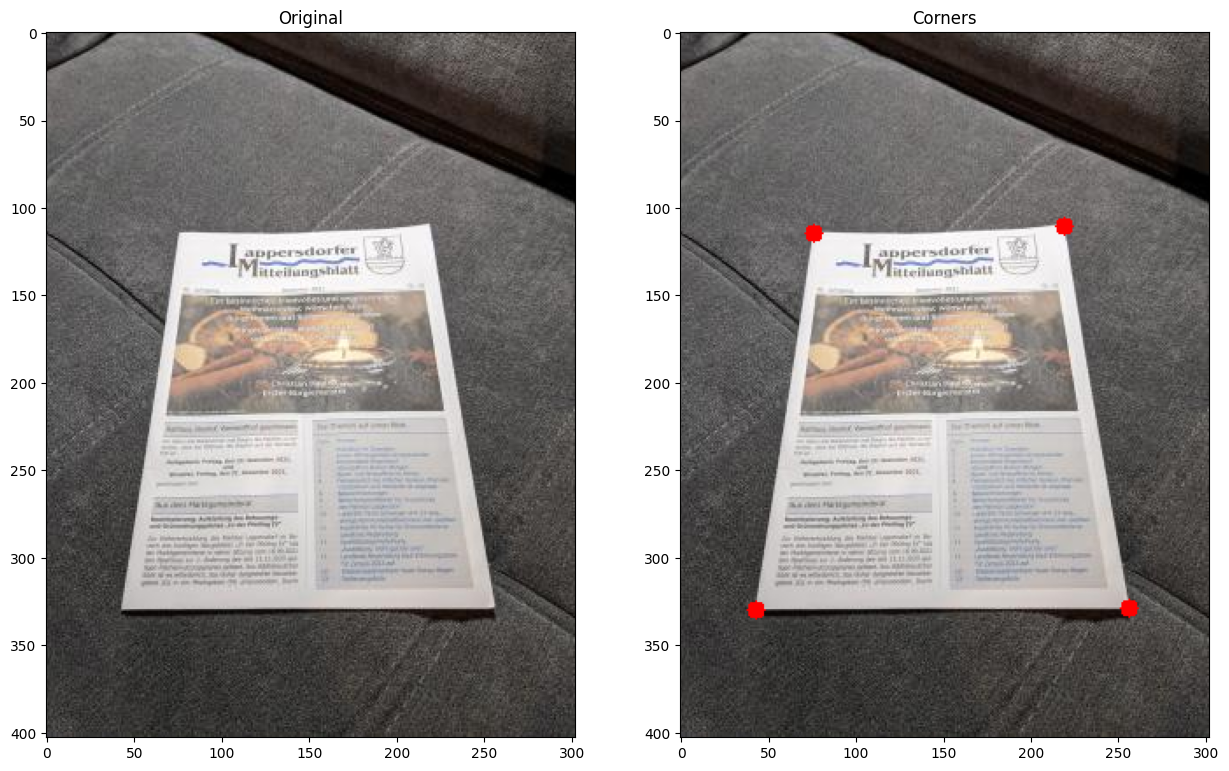

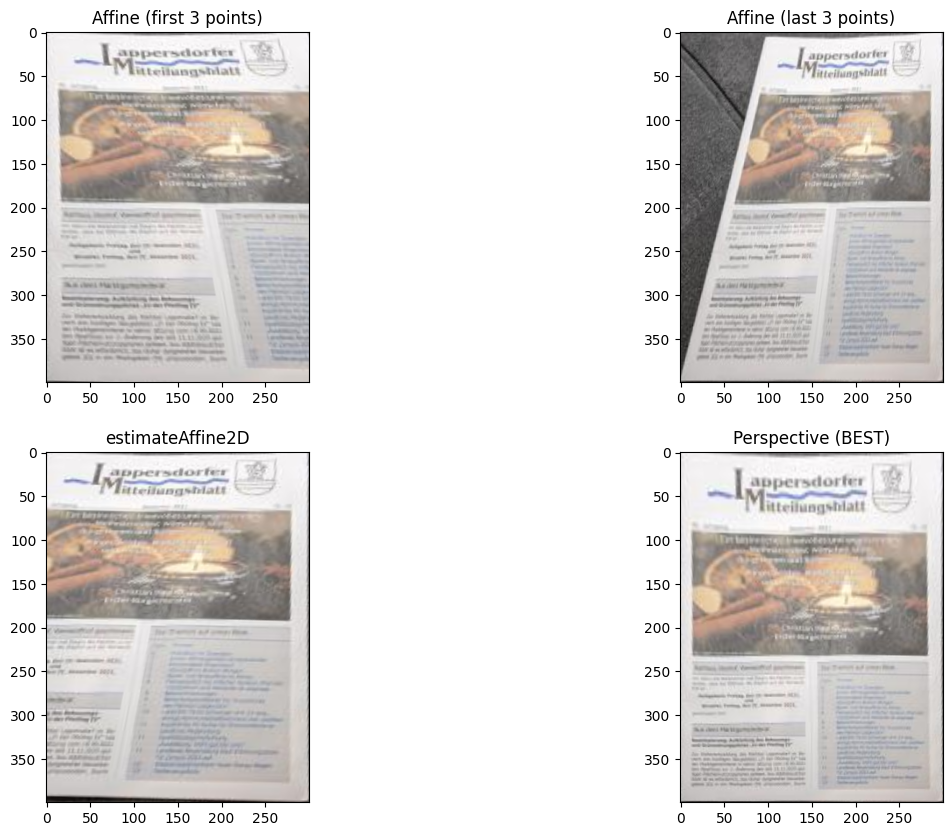

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread('document (1).jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray) / 255
rows, cols = gray.shape

top_left = [76, 115]
top_right = [219, 111]
bottom_left = [43, 330]
bottom_right = [256, 329]

out = img.copy()
for pt in [top_left, top_right, bottom_left, bottom_right]:
    out = cv2.circle(out, tuple(pt), 5, (255, 0, 0), -1)

plt.subplot(121), plt.title("Original")
plt.imshow(img)

plt.subplot(122), plt.title("Corners")
plt.imshow(out)
plt.show()

src = np.array([
    top_left,
    top_right,
    bottom_left,
    bottom_right
], dtype=np.float32)

width = 300
height = 400

dst = np.array([
    [0, 0],
    [width - 1, 0],
    [0, height - 1],
    [width - 1, height - 1]
], dtype=np.float32)

M1 = cv2.getAffineTransform(src[:3], dst[:3])
affine1 = cv2.warpAffine(img, M1, (width, height))

M2 = cv2.getAffineTransform(src[1:], dst[1:])
affine2 = cv2.warpAffine(img, M2, (width, height))

M3, inliers = cv2.estimateAffine2D(src, dst)
affine3 = cv2.warpAffine(img, M3, (width, height))

M4 = cv2.getPerspectiveTransform(src, dst)
perspective = cv2.warpPerspective(img, M4, (width, height))

plt.figure(figsize=(15, 10))

plt.subplot(221), plt.title("Affine (first 3 points)")
plt.imshow(affine1)

plt.subplot(222), plt.title("Affine (last 3 points)")
plt.imshow(affine2)

plt.subplot(223), plt.title("estimateAffine2D")
plt.imshow(affine3)

plt.subplot(224), plt.title("Perspective (BEST)")
plt.imshow(perspective)

plt.show()

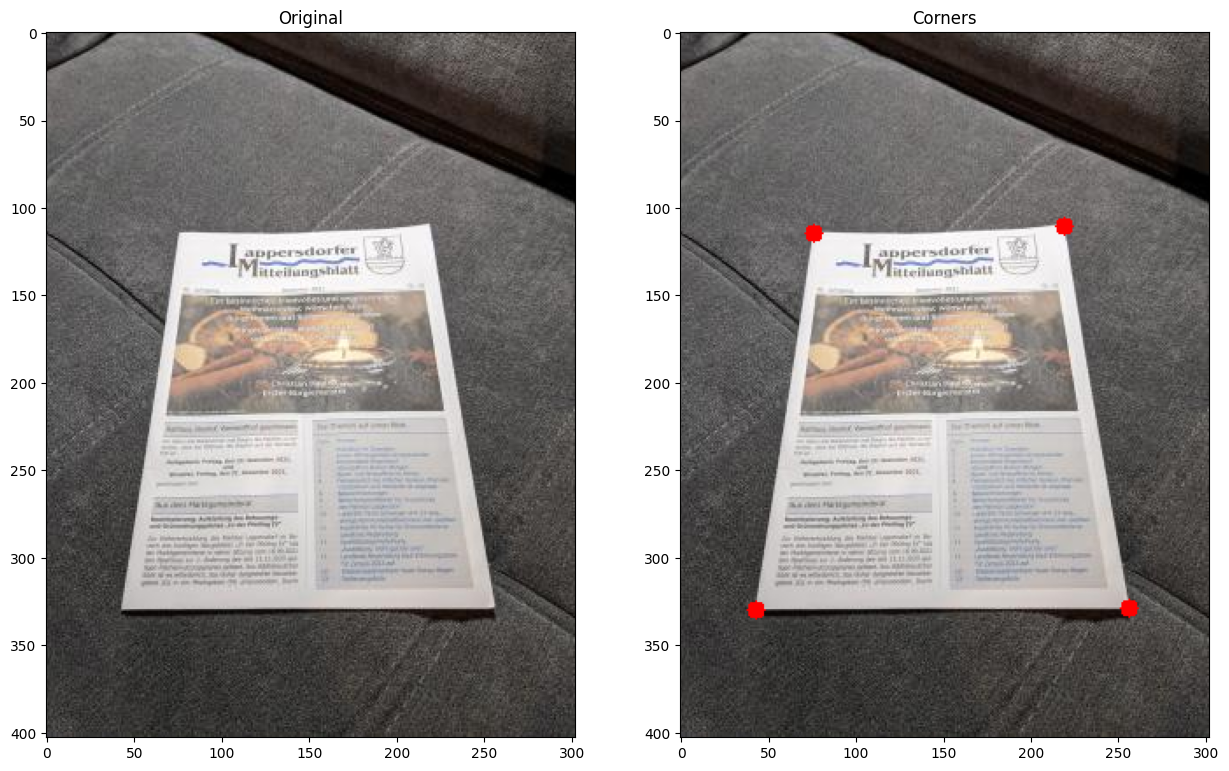

Affine matrix (first 3 points):
 [[ 2.09992487e+00  3.22314050e-01 -1.96660406e+02]
 [ 5.21347140e-02  1.86381603e+00 -2.18301081e+02]]

Affine matrix (last 3 points):
 [[ 1.40263820e+00 -2.38062448e-01  1.82471649e+01]
 [ 8.58599987e-03  1.82881797e+00 -2.04879129e+02]]

estimateAffine2D matrix:
 [[ 2.08102931e+00 -3.53202222e-01 -1.17539972e+02]
 [ 5.09546006e-02  1.82162697e+00 -2.13359651e+02]]

Inliers:
 [[1]
 [1]
 [0]
 [1]]

Perspective matrix:
 [[ 2.94054111e+00  4.51338869e-01 -2.75385095e+02]
 [ 1.06661087e-01  3.81313387e+00 -4.46616638e+02]
 [ 2.37188082e-04  3.13841065e-03  1.00000000e+00]]


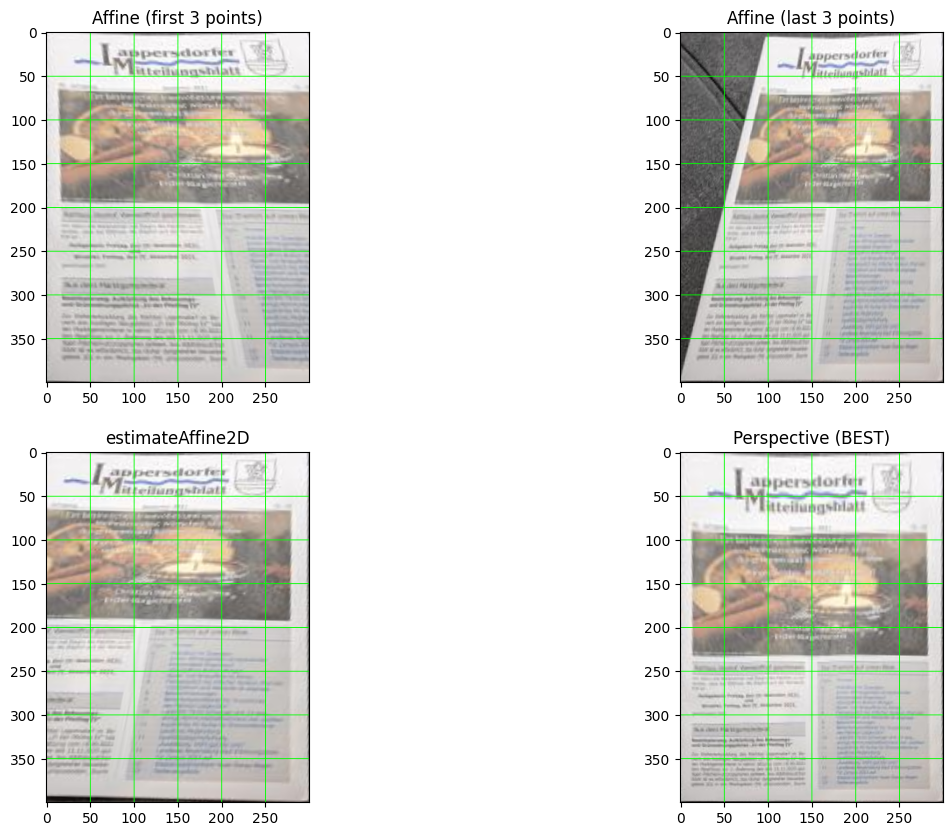

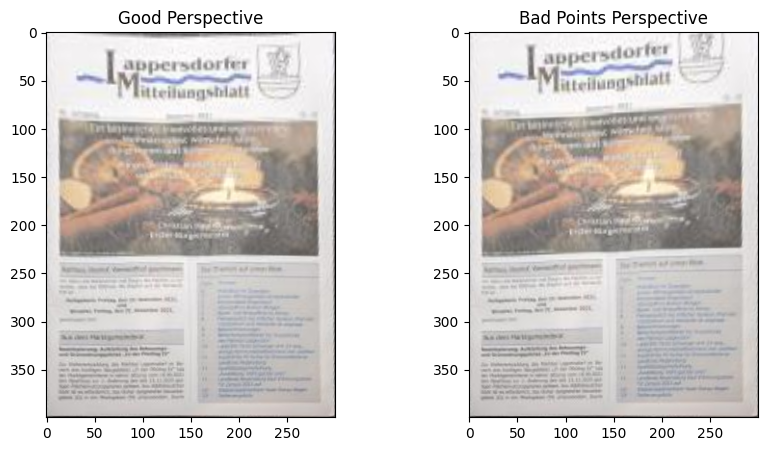

In [3]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

img = cv2.imread('document (1).jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

top_left = [76, 115]
top_right = [219, 111]
bottom_left = [43, 330]
bottom_right = [256, 329]

out = img.copy()
for pt in [top_left, top_right, bottom_left, bottom_right]:
    out = cv2.circle(out, tuple(pt), 5, (255, 0, 0), -1)

plt.subplot(121), plt.title("Original")
plt.imshow(img)

plt.subplot(122), plt.title("Corners")
plt.imshow(out)
plt.show()

src = np.array([
    top_left,
    top_right,
    bottom_left,
    bottom_right
], dtype=np.float32)

width = 300
height = 400

dst = np.array([
    [0, 0],
    [width - 1, 0],
    [0, height - 1],
    [width - 1, height - 1]
], dtype=np.float32)

M1 = cv2.getAffineTransform(src[:3], dst[:3])
affine1 = cv2.warpAffine(img, M1, (width, height))

M2 = cv2.getAffineTransform(src[1:], dst[1:])
affine2 = cv2.warpAffine(img, M2, (width, height))

M3, inliers = cv2.estimateAffine2D(src, dst)
affine3 = cv2.warpAffine(img, M3, (width, height))

M4 = cv2.getPerspectiveTransform(src, dst)
perspective = cv2.warpPerspective(img, M4, (width, height))

print("Affine matrix (first 3 points):\n", M1)
print("\nAffine matrix (last 3 points):\n", M2)
print("\nestimateAffine2D matrix:\n", M3)
print("\nInliers:\n", inliers)
print("\nPerspective matrix:\n", M4)
def draw_grid(img, step=50):
    img_copy = img.copy()
    h, w = img.shape[:2]

    for i in range(0, w, step):
        cv2.line(img_copy, (i, 0), (i, h), (0, 255, 0), 1)

    for j in range(0, h, step):
        cv2.line(img_copy, (0, j), (w, j), (0, 255, 0), 1)

    return img_copy
plt.figure(figsize=(15, 10))

plt.subplot(221), plt.title("Affine (first 3 points)")
plt.imshow(draw_grid(affine1))

plt.subplot(222), plt.title("Affine (last 3 points)")
plt.imshow(draw_grid(affine2))

plt.subplot(223), plt.title("estimateAffine2D")
plt.imshow(draw_grid(affine3))

plt.subplot(224), plt.title("Perspective (BEST)")
plt.imshow(draw_grid(perspective))

plt.show()

src_bad = np.array([
    [76, 115],
    [219, 120],
    [43, 330],
    [256, 329]
], dtype=np.float32)

M_bad = cv2.getPerspectiveTransform(src_bad, dst)
perspective_bad = cv2.warpPerspective(img, M_bad, (width, height))

plt.figure(figsize=(10, 5))

plt.subplot(121), plt.title("Good Perspective")
plt.imshow(perspective)

plt.subplot(122), plt.title("Bad Points Perspective")
plt.imshow(perspective_bad)

plt.show()

Висновок:

Афінне перетворення не дає задовільного результату для вирівнювання документа, оскільки воно не враховує перспективні спотворення. Результат залежить від вибору трьох точок і не є стабільним.

Вектор inliers, отриманий за допомогою estimateAffine2D, показує, які точки узгоджуються з афінною моделлю. Наявність outliers свідчить про те, що модель не може коректно описати всі точки через наявність перспективних спотворень.

Гомографія демонструє значно кращий результат. Вона дозволяє правильно вирівняти документ, усунути перспективні викривлення і отримати зображення, яке виглядає як відскановане.

Отже, для задач вирівнювання документів доцільно використовувати гомографію, а не афінне перетворення